# 01 - Data Preparation and Final Fakeddit Subset


> Reproducibility note: expensive training commands are shown as code or comments. For viva, these notebooks load the saved final outputs committed in the repository, so the panel can inspect the evidence without rerunning hours of training.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Works in Colab and in a local clone. In Colab, uncomment the mount lines if needed.
try:
    from google.colab import drive  # type: ignore
    # drive.mount('/content/drive')
    COLAB_ROOT = Path('/content/drive/MyDrive/fake-news-rl-fusion')
    PROJECT_ROOT = COLAB_ROOT if COLAB_ROOT.exists() else Path.cwd().resolve().parent
except Exception:
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

print('PROJECT_ROOT =', PROJECT_ROOT)

def read_json(relative_path):
    with open(PROJECT_ROOT / relative_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def read_csv(relative_path):
    return pd.read_csv(PROJECT_ROOT / relative_path)

def show_metrics(metrics, keys=('macro_f1', 'accuracy', 'roc_auc', 'balanced_accuracy')):
    rows = []
    for key in keys:
        if key in metrics:
            rows.append({'metric': key, 'value': metrics[key]})
    display(pd.DataFrame(rows))

PROJECT_ROOT = C:\Users\acer\Documents\GitHub\fake-news-rl-fusion


## Purpose
This notebook documents the dataset used for the final experiments: Fakeddit metadata preparation, label standardization, train/validation/test splits, image availability, and leakage checks.

In [2]:
stats = read_json('outputs/metrics/fakeddit_stats.json')
summary = read_json('outputs/tables/final_results_summary.json')
print('Dataset:', stats.get('dataset'))
print('Total rows after preparation:', stats.get('total_rows'))
print('Label standard:', stats.get('label_standard'))
display(pd.DataFrame(summary['dataset_summary']['splits']).T)

Dataset: Fakeddit multimodal_only_samples
Total rows after preparation: 682661
Label standard: {'0': 'Real', '1': 'Fake'}


,class_distribution,rows
test,"{'0': 23507, '1': 35812}",59319
train,"{'0': 222081, '1': 341919}",564000
validation,"{'0': 23320, '1': 36022}",59342


,label,count
0,0,268908
1,1,413753


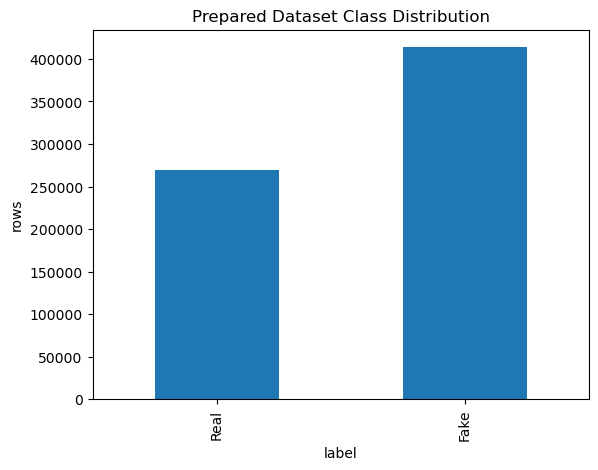

In [3]:
class_dist = pd.Series(summary['dataset_summary']['class_distribution'], name='count').rename_axis('label').reset_index()
display(class_dist)
ax = class_dist.assign(label=class_dist['label'].map({'0': 'Real', '1': 'Fake'})).plot.bar(x='label', y='count', legend=False, title='Prepared Dataset Class Distribution')
ax.set_ylabel('rows')
plt.show()

In [4]:
image_download = summary['dataset_summary'].get('debug_image_download', {})
display(pd.DataFrame([image_download]))
print('Final downloaded/available multimodal rows used:', image_download.get('available_rows'))

,available_rows,downloaded,failed,requested
0,26471,26471,1529,28000


Final downloaded/available multimodal rows used: 26471


In [5]:
leakage = stats.get('cross_split_leakage', {})
display(pd.DataFrame([leakage]).T.rename(columns={0: 'overlap_count'}))

,overlap_count
train_vs_test_image_path_overlap,0
train_vs_test_sample_id_overlap,0
train_vs_test_text_overlap,4754
train_vs_validation_image_path_overlap,0
train_vs_validation_sample_id_overlap,0
train_vs_validation_text_overlap,4647
validation_vs_test_image_path_overlap,0
validation_vs_test_sample_id_overlap,0
validation_vs_test_text_overlap,1380


## Reproduction Commands
Run these only when rebuilding the dataset in Colab:

In [6]:
# %cd /content/drive/MyDrive/fake-news-rl-fusion
# !python scripts/prepare_fakeddit.py --config configs/fakeddit.yaml
# !python scripts/create_debug_subset.py --config configs/final_subset.yaml
# !python scripts/download_images.py --config configs/final_image_download.yaml